# 01b · Reconstruct a Factor from the Underlying Portfolios

A **Fama-French factor** is just the return of a long-short portfolio. 
In this notebook we rebuild one ourselves from the raw sorted portfolios and check it matches the
official series.

The French library publishes the building blocks. The `HML` and (3-factor)
`SMB` factors both come from a single **2×3 sort on Size × Book-to-Market**, which
French publishes as the dataset **`6_Portfolios_2x3`**. We'll:

1. Load those 6 value-weighted portfolios + the official 3-factor file.
2. Apply the construction formulas by hand.
3. Compare our reconstruction to the published `HML` and `SMB`.

> We compare against the **3-factor** file (not the 5-factor one): the 3-factor `SMB`
> comes from exactly this one sort, so it should match. The 5-factor `SMB` averages
> three different sorts, so it would *not*.


## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import get_french

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

/Users/Parimah/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/Parimah/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Step 1 · Load the building blocks

`6_Portfolios_2x3` gives 6 value-weighted portfolios: Size {Small, Big} ×
B/M {Low, Neutral, High}.

In [2]:
p   = get_french("6_Portfolios_2x3")
ff3 = get_french("F-F_Research_Data_Factors")

print("6 portfolios:", list(p.columns))
print("3-factor    :", list(ff3.columns))
print("aligned dates:", p.index.equals(ff3.index), "|", len(p), "months")
p.head()

6 portfolios: ['SMALL LoBM', 'ME1 BM2', 'SMALL HiBM', 'BIG LoBM', 'ME2 BM2', 'BIG HiBM']
3-factor    : ['Mkt-RF', 'SMB', 'HML', 'RF']
aligned dates: True | 738 months


,SMALL LoBM,ME1 BM2,SMALL HiBM,BIG LoBM,ME2 BM2,BIG HiBM
Date,,,,,,
1963-07-31 23:59:59.999999,-1.0784,-0.6851,-1.1211,-0.0442,0.4928,-1.6215
1963-08-31 23:59:59.999999,4.4536,4.4942,5.7902,5.4111,4.6924,7.4788
1963-09-30 23:59:59.999999,-2.8511,-0.5305,-2.0329,-1.0686,-1.7131,-1.8902
1963-10-31 23:59:59.999999,0.9896,1.7372,2.7197,3.8506,1.2648,2.0440
1963-11-30 23:59:59.999999,-2.8797,-1.2668,-0.3645,-0.2568,-1.4638,0.6870


### Map the 6 columns to the 2×3 grid

| Size \\ B/M | Low (Growth) | Neutral | High (Value) |
|---|---|---|---|
| **Small** | `SMALL LoBM` | `ME1 BM2` | `SMALL HiBM` |
| **Big**   | `BIG LoBM`   | `ME2 BM2` | `BIG HiBM`   |

Shorthand: **S**mall/**B**ig × **L**ow/**N**eutral/**H**igh → SL, SN, SH, BL, BN, BH.

## Step 2 · Apply the construction formulas

$$\text{HML} = \tfrac{1}{2}(SH + BH) - \tfrac{1}{2}(SL + BL) \quad\text{(value − growth, averaged over size)}$$

$$\text{SMB} = \tfrac{1}{3}(SL + SN + SH) - \tfrac{1}{3}(BL + BN + BH) \quad\text{(small − big, averaged over B/M)}$$

In [3]:
SL, SN, SH = p["SMALL LoBM"], p["ME1 BM2"], p["SMALL HiBM"]
BL, BN, BH = p["BIG LoBM"],   p["ME2 BM2"], p["BIG HiBM"]

HML_mine = (SH + BH) / 2 - (SL + BL) / 2
SMB_mine = (SL + SN + SH) / 3 - (BL + BN + BH) / 3

recon = pd.DataFrame({"HML_mine": HML_mine, "HML_official": ff3["HML"],
                      "SMB_mine": SMB_mine, "SMB_official": ff3["SMB"]})
recon.head()

,HML_mine,HML_official,SMB_mine,SMB_official
Date,,,,
1963-07-31 23:59:59.999999,-0.8100,-0.8100,-0.5706,-0.5700
1963-08-31 23:59:59.999999,1.7021,1.7000,-0.9481,-0.9500
1963-09-30 23:59:59.999999,-0.0017,0.0000,-0.2475,-0.2500
1963-10-31 23:59:59.999999,-0.0383,-0.0400,-0.5710,-0.5700
1963-11-30 23:59:59.999999,1.7295,1.7300,-1.1591,-1.1600


## Step 3 · Compare to the official factors

In [4]:
for name in ["HML", "SMB"]:
    mine, off = recon[f"{name}_mine"], recon[f"{name}_official"]
    diff = mine - off
    print(f"{name}: max abs diff = {diff.abs().max():.4f}  "
          f"mean abs diff = {diff.abs().mean():.4f}  "
          f"corr = {mine.corr(off):.6f}")

HML: max abs diff = 0.0050  mean abs diff = 0.0025  corr = 1.000000
SMB: max abs diff = 0.0050  mean abs diff = 0.0025  corr = 1.000000


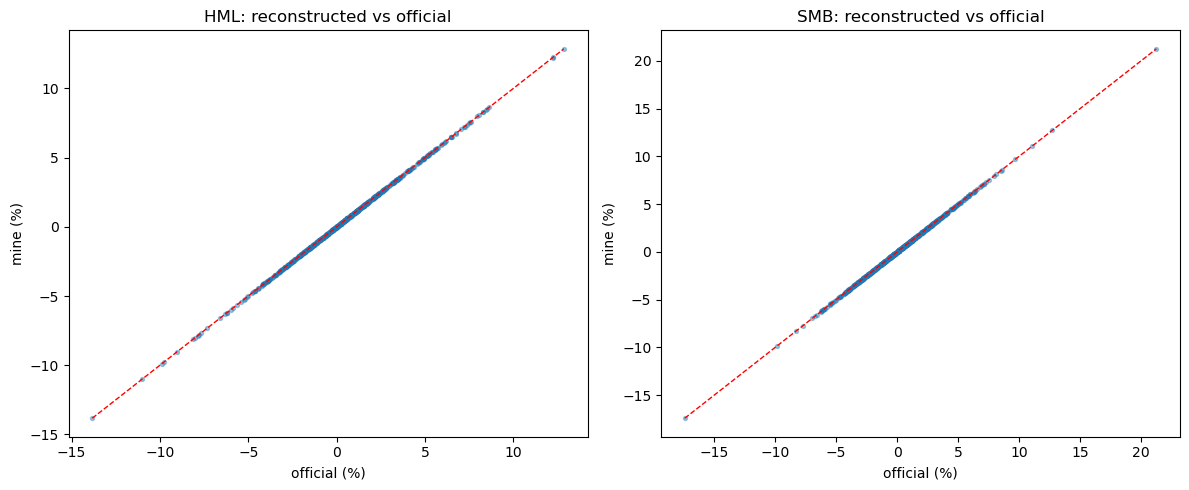

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ["HML", "SMB"]):
    ax.scatter(recon[f"{name}_official"], recon[f"{name}_mine"], s=8, alpha=0.4)
    lo, hi = recon[[f"{name}_official", f"{name}_mine"]].min().min(), recon[[f"{name}_official", f"{name}_mine"]].max().max()
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set(title=f"{name}: reconstructed vs official", xlabel="official (%)", ylabel="mine (%)")
plt.tight_layout()

## Takeaway

The reconstruction matches the published series to within rounding (tiny diffs come
from French rounding the published portfolio returns to 2 decimals). This makes the
mechanism concrete: **a factor is nothing more than a value-weighted long-short
portfolio return** — long the favored bucket, short the other, averaged across the
size dimension to stay roughly size-neutral.
